In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Mounted at /content/drive


In [5]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset_citra"

image_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".jpg")]

df = pd.DataFrame({"image": image_files})
df["path"] = df["image"].apply(lambda x: os.path.join(DATASET_PATH, x))

In [6]:
def extract_color_hsv(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img = cv2.resize(img, (80,80))
    pixels = img.reshape((-1,3))

    kmeans = KMeans(n_clusters=3, n_init=10)
    kmeans.fit(pixels)

    colors = kmeans.cluster_centers_
    labels = kmeans.labels_
    counts = np.bincount(labels)

    dominant = colors[np.argmax(counts)]
    return dominant

In [7]:
colors = df["path"].apply(extract_color_hsv)

df["H"] = colors.apply(lambda x: int(x[0]))
df["S"] = colors.apply(lambda x: int(x[1]))
df["V"] = colors.apply(lambda x: int(x[2]))

In [8]:
def get_color_label(h, s, v):
    if v < 50:
        return "Hitam"
    elif s < 50:
        return "Abu-abu"
    elif v > 200 and s < 50:
        return "Putih"
    elif h < 10 or h >= 160:
        return "Merah"
    elif h < 25:
        return "Orange"
    elif h < 35:
        return "Kuning"
    elif h < 85:
        return "Hijau"
    elif h < 125:
        return "Biru"
    else:
        return "Ungu"

In [9]:
df["color_label"] = df.apply(
    lambda x: get_color_label(x["H"], x["S"], x["V"]), axis=1
)

In [10]:
kmeans_flowers = KMeans(n_clusters=5, random_state=42)
df["flower_cluster"] = kmeans_flowers.fit_predict(df[["H","S","V"]])

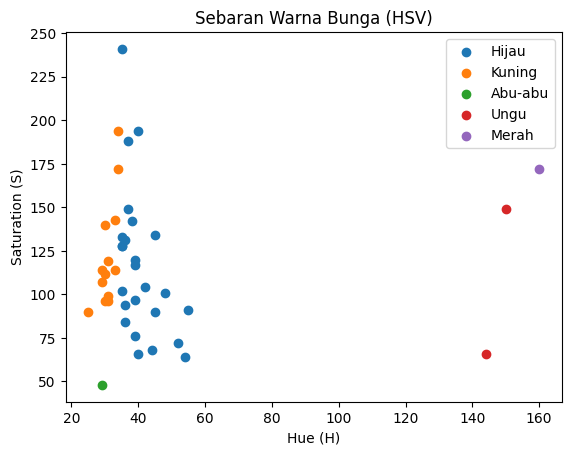

In [11]:
plt.figure()

for color in df["color_label"].unique():
    subset = df[df["color_label"] == color]
    plt.scatter(subset["H"], subset["S"], label=color)

plt.legend()
plt.xlabel("Hue (H)")
plt.ylabel("Saturation (S)")
plt.title("Sebaran Warna Bunga (HSV)")

plt.show()

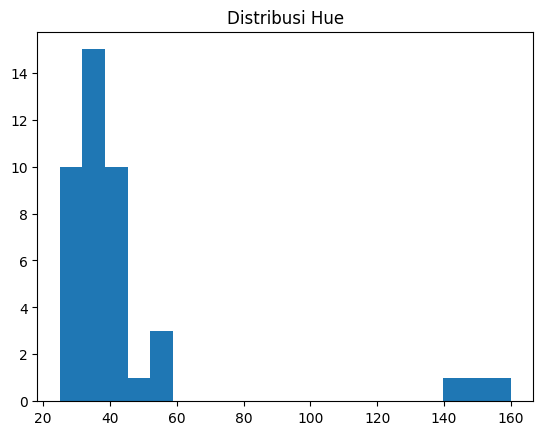

In [12]:
plt.figure()

plt.hist(df["H"], bins=20)
plt.title("Distribusi Hue")

plt.show()

In [13]:
df.to_csv("/content/drive/MyDrive/hasil_ekstraksi.csv", index=False)